<a href="https://colab.research.google.com/github/Javier841/Practica_Final/blob/main/Presentaci%C3%B3n_de_resultados_de_un_proyecto_de_ciencia_de_datos_Javier_Heredia_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [101]:
# 1. IMPORTO LIBRERÍAS
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid", palette="muted")  # estilo storytelling

In [102]:
# 2. CARGO Y LIMPIO LOS DATOS
df = pd.read_csv("MarathonData.csv")

# Conservo solo las columnas necesarias
df = df[['km4week', 'sp4week', 'Wall21', 'MarathonTime', 'CrossTraining']]

# Paso 1: Convierto Wall21 a numérico
df['Wall21'] = pd.to_numeric(df['Wall21'], errors='coerce')

# Paso 2: Elimino outliers extremos
df = df[df['sp4week'] < 100]

# Paso 3: Imputo los valores faltantes en CrossTraining con "0" (sin entrenamiento cruzado)
df['CrossTraining'] = df['CrossTraining'].fillna("0")

# Paso 4: Codifico CrossTraining como variable numérica
le = LabelEncoder()
df['CrossTraining'] = le.fit_transform(df['CrossTraining'])

# Paso 5: Elimino cualquier otro nulo restante
df.dropna(inplace=True)

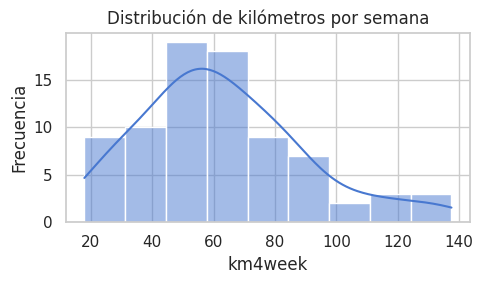

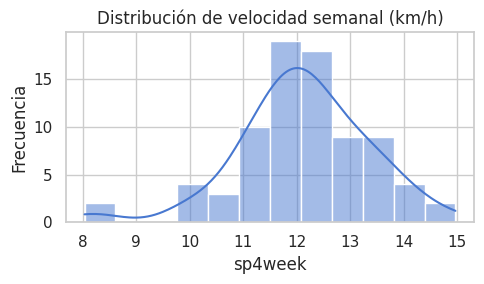

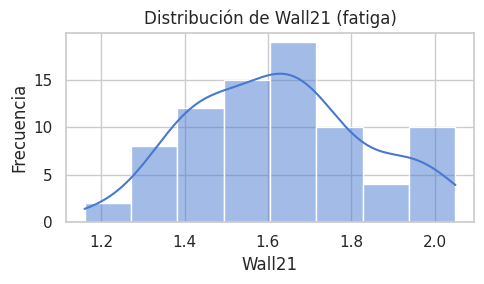

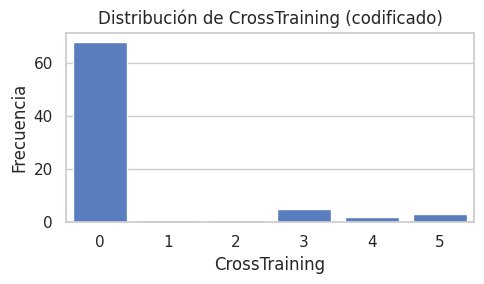

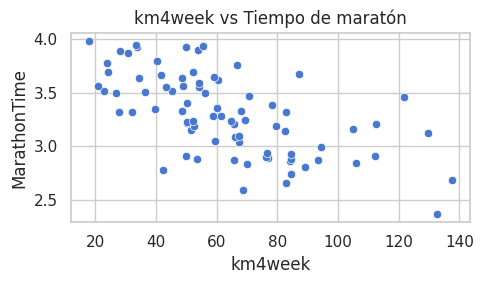

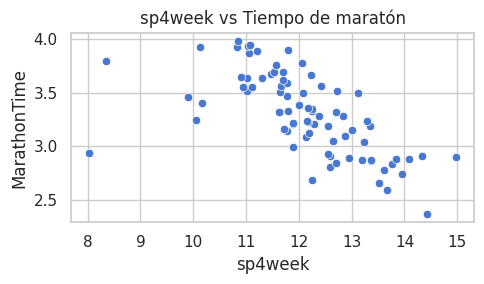

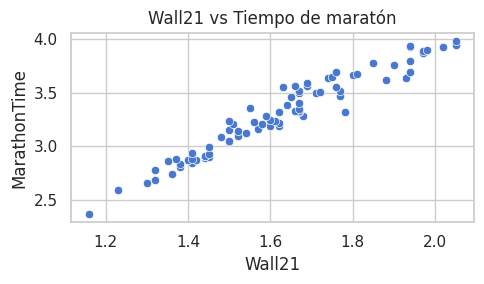

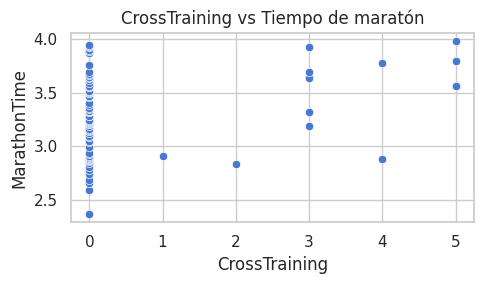

In [103]:
# 3. EDA VISUAL CON STORYTELLING
# Distribución de km/semana
plt.figure(figsize=(5,3))
sns.histplot(df['km4week'], kde=True)
plt.title('Distribución de kilómetros por semana')
plt.xlabel('km4week')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# Distribución de velocidad semanal
plt.figure(figsize=(5,3))
sns.histplot(df['sp4week'], kde=True)
plt.title('Distribución de velocidad semanal (km/h)')
plt.xlabel('sp4week')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# Distribución de Wall21
plt.figure(figsize=(5,3))
sns.histplot(df['Wall21'], kde=True)
plt.title('Distribución de Wall21 (fatiga)')
plt.xlabel('Wall21')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# Distribución de CrossTraining (codificado)
plt.figure(figsize=(5,3))
sns.countplot(x='CrossTraining', data=df)
plt.title('Distribución de CrossTraining (codificado)')
plt.xlabel('CrossTraining')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# Relación entre variables y MarathonTime
for col in ['km4week', 'sp4week', 'Wall21', 'CrossTraining']:
    plt.figure(figsize=(5,3))
    sns.scatterplot(x=col, y='MarathonTime', data=df)
    plt.title(f'{col} vs Tiempo de maratón')
    plt.xlabel(col)
    plt.ylabel('MarathonTime')
    plt.tight_layout()
    plt.show()

In [104]:
# 4. CORRELACIONES
print("Correlaciones con MarathonTime:")
print(df.corr(numeric_only=True)['MarathonTime'].sort_values(ascending=False))

Correlaciones con MarathonTime:
MarathonTime     1.000000
Wall21           0.968751
CrossTraining    0.254873
km4week         -0.623238
sp4week         -0.639466
Name: MarathonTime, dtype: float64


In [105]:
# 5. PREPARO LOS DATOS PARA EL MODELO
X = df[['km4week', 'sp4week', 'Wall21', 'CrossTraining']]
y = df['MarathonTime']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [106]:
# 6. ENTRENO LOS MODELOS
modelos = {
    'Regresión Lineal': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42)
}

resultados = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    resultados[nombre] = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': mse ** 0.5,
        'R2': r2_score(y_test, y_pred)
    }

print("\nComparación de modelos:")
print(pd.DataFrame(resultados).T)


Comparación de modelos:
                        MAE      RMSE        R2
Regresión Lineal   0.078769  0.091641  0.936292
Random Forest      0.089853  0.111357  0.905931
Gradient Boosting  0.082986  0.102928  0.919632


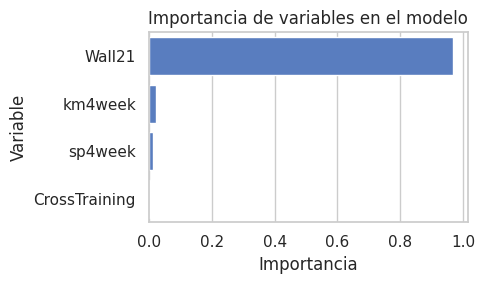


Importancia de las variables:
        Variable  Importancia
2         Wall21     0.966764
0        km4week     0.020705
1        sp4week     0.011268
3  CrossTraining     0.001263


In [107]:
# 7. IMPORTANCIA DE VARIABLES EN MODELO GANADOR
mejor_modelo = GradientBoostingRegressor(n_estimators=200, random_state=42)
mejor_modelo.fit(X_train_scaled, y_train)

importancias = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': mejor_modelo.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(5, 3))
sns.barplot(x='Importancia', y='Variable', data=importancias)
plt.title('Importancia de variables en el modelo')
plt.tight_layout()
plt.show()

print("\nImportancia de las variables:")
print(importancias)


In [108]:
# 8. CONCLUSIONES
print("\nConclusiones:")
print("- Vemos que Wall21, sp4week y km4week son las variables más relevantes.")
print("- CrossTraining tiene baja importancia, por lo que su aporte al modelo es limitado.")
print("- Gradient Boosting es el mejor modelo en cuanto al aporte de cada variable y su combinación con precisión.")



Conclusiones:
- Vemos que Wall21, sp4week y km4week son las variables más relevantes.
- CrossTraining tiene baja importancia, por lo que su aporte al modelo es limitado.
- Gradient Boosting es el mejor modelo en cuanto al aporte de cada variable y su combinación con precisión.
